# Integrated DRRM Business Intelligence Dashboard
**Biñan City, Laguna**

**Group Members:** Funelas, Rivera, Torculas

## 1. Introduction and BI Context
This project presents an **Operational and Tactical BI Dashboard** for the Disaster Risk Reduction and Management Office (DRRMO) of **Biñan City, Laguna**. 
Biñan City is vulnerable to hazards like flooding (due to its proximity to Laguna de Bay) and fires. 
This dashboard serves decision-makers by allowing them to:
- Monitor daily incidents and operational load.
- Identify high-risk barangays requiring immediate mitigation.
- Evaluate rescue team readiness and facility capacities.

**Target Audience:** DRRMO Officers, City Planners, and Incident Commanders.
**Time Horizon:** Daily to Periodic (for monitoring current load and short-term tactical planning).


In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import ipywidgets as widgets
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 2. Data Loading and ETL (Extract, Transform, Load)
We extract data from our four core CSV files: `barangays1.csv`, `facilities1.csv`, `rescue_teams1.csv`, and `incidents1.csv`.
In this ETL process, we handle missing values (e.g., filling missing `NumAffected` with the median), convert data types (e.g., `DateTime` conversion), and calculate a derived `Risk Score` for each barangay.


In [176]:
# Load Data
df_brgy = pd.read_csv('barangays1.csv')
df_fac = pd.read_csv('facilities1.csv')
df_teams = pd.read_csv('rescue_teams1.csv')
df_incidents = pd.read_csv('incidents1.csv')

# 1. Inspect Data
print("Incidents Dataset Shape:", df_incidents.shape)

# 2. Transform: Datatype conversion
df_incidents['DateTime'] = pd.to_datetime(df_incidents['DateTime'])
df_incidents['Month'] = df_incidents['DateTime'].dt.to_period('M').astype(str)

# 3. Transform: Handling Missing Values (Simulating ETL cleaning)
# Fill missing NumAffected with the median of that specific incident type
df_incidents['NumAffected'] = df_incidents.groupby('Type')['NumAffected'].transform(lambda x: x.fillna(x.median()))

# 4. Transform: Deriving new metrics (Risk Score)
# Risk Score = (Hazard Level weight) * (Population / 1000)
hazard_weights = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df_brgy['HazardWeight'] = df_brgy['HazardLevel'].map(hazard_weights)
df_brgy['RiskScore'] = df_brgy['HazardWeight'] * (df_brgy['Population'] / 1000)
df_brgy['RiskScore'] = df_brgy['RiskScore'].round(2)

print("Data cleaning and ETL complete. Ready for analysis.")


Incidents Dataset Shape: (251, 8)
Data cleaning and ETL complete. Ready for analysis.


## 3. KPIs and Metrics
These metrics reflect the BI monitoring goals for our tactical dashboard:
1. **Total Incidents:** Monitors overall operational load.
2. **Total Affected Population:** Identifies impact severity.
3. **Total Available Rescue Teams:** Checks readiness.
4. **Total Facility Capacity:** Evaluates resource adequacy.
5. **Highest Risk Barangay:** Prioritizes mitigation focus.


In [177]:
# Calculate 10 KPIs for BI Dashboard
total_incidents = len(df_incidents)
total_affected = int(df_incidents['NumAffected'].sum())
available_teams = len(df_teams[df_teams['OnDuty/Availability'] == 'Available'])
total_capacity = df_fac['Capacity'].sum()
highest_risk_brgy = df_brgy.sort_values(by='RiskScore', ascending=False).iloc[0]['Barangay']
total_evac_centers = len(df_fac[df_fac['Capacity']*0.9 > df_fac['Occupants']])
water_rescue_teams = len(df_teams[df_teams['Specialty'] == 'Water Rescue'])
critical_incidents = len(df_incidents[df_incidents['Severity'] == 'Critical'])
total_occupants = int(df_fac['Occupants'].sum())
occ_pct = round((total_occupants / df_fac['Capacity'].sum()) * 100, 1)
facilities_needing_resupply = len(df_fac[df_fac['ResourcesAvailable'] < 30])

kpis = [
    {"icon": "🚨", "label": "Total Incidents",    "value": total_incidents,       "color": "#e53e3e", "bg": "#fff5f5", "badge": "Operational", "badge_color": "#e53e3e"},
    {"icon": "👥", "label": "Total Affected",      "value": total_affected,        "color": "#dd6b20", "bg": "#fffaf0", "badge": "Impact",       "badge_color": "#dd6b20"},
    {"icon": "🟢", "label": "Available Teams",     "value": available_teams,       "color": "#276749", "bg": "#f0fff4", "badge": "Readiness",    "badge_color": "#276749"},
    {"icon": "🏥", "label": "Total Capacity",      "value": total_capacity,        "color": "#2b6cb0", "bg": "#ebf8ff", "badge": "Resources",    "badge_color": "#2b6cb0"},
    {"icon": "⚠",     "label": "Critical Incidents",  "value": critical_incidents,    "color": "#822727", "bg": "#fff5f5", "badge": "Critical",     "badge_color": "#822727"},
    {"icon": "🏠", "label": "Evac Centers",        "value": total_evac_centers,    "color": "#276749", "bg": "#f0fff4", "badge": "Active",       "badge_color": "#276749"},
    {"icon": "🌊", "label": "Water Rescue Teams",  "value": water_rescue_teams,    "color": "#2c5282", "bg": "#ebf8ff", "badge": "Specialized",  "badge_color": "#2c5282"},
    {"icon": "📍", "label": "Highest Risk Brgy",   "value": highest_risk_brgy,     "color": "#744210", "bg": "#fffff0", "badge": "Priority",     "badge_color": "#744210"},
    {"icon": "📊", "label": "Occupants / Capacity", "value": f"{occ_pct}%", "color": "#553c9a", "bg": "#faf5ff", "badge": "Occupancy",    "badge_color": "#553c9a"},
    {"icon": "🚦", "label": "Need Resupply",        "value": facilities_needing_resupply,                                    "color": "#234e52", "bg": "#e6fffa", "badge": "Resources",    "badge_color": "#234e52"},
]

cards_html = ""
for kpi in kpis:
    cards_html += (
        '<div style="background:' + kpi['bg'] + '; border-radius:12px; padding:16px 20px; width:180px;'
        ' box-shadow:0 2px 8px rgba(0,0,0,0.08); display:flex; flex-direction:column; gap:8px;'
        ' border-left:5px solid ' + kpi['color'] + ';">' +
        '<div style="display:flex; align-items:center; gap:10px;">'
        '<span style="font-size:26px;">' + kpi['icon'] + '</span>'
        '<div>'
        '<div style="font-size:22px; font-weight:800; color:' + kpi['color'] + '; line-height:1.1;">' + str(kpi['value']) + '</div>'
        '<div style="font-size:12px; color:#4a5568; font-weight:500; margin-top:2px;">' + kpi['label'] + '</div>'
        '</div></div>'
        '<div style="align-self:flex-start; background:' + kpi['color'] + '18; color:' + kpi['badge_color'] + ';'
        ' font-size:10px; font-weight:700; padding:3px 8px; border-radius:20px; letter-spacing:0.5px;">' + kpi['badge'] + '</div>'
        '</div>'
    )

html_kpi = (
    '<div style="font-family:Segoe UI,sans-serif; background:#f7fafc; padding:24px; border-radius:16px;">'
    '<div style="margin-bottom:20px;">'
    '<h2 style="margin:0; color:#1a202c; font-size:20px;">📋 DRRM Strategic Performance Indicators</h2>'
    '<p style="margin:4px 0 0; color:#718096; font-size:13px;">Biñan City DRRMO — Operational Dashboard</p>'
    '</div>'
    '<div style="display:flex; flex-wrap:wrap; gap:16px; justify-content: center">'
    + cards_html +
    '</div></div>'
)
display(HTML(html_kpi))


## 3.5 Summary Tables
The following tables provide structured monitoring of city resources, as required by the DRRM BI framework.
This includes: Evacuation Sites, Schools, Command Centers, Hospitals, Health Care Centers, and Fire Stations.


In [178]:
# Summary Table 1: Facilities per Barangay and Type
fac_summary = df_fac.groupby(['Barangay', 'Type']).size().unstack(fill_value=0)
display(HTML("<h3>Summary: Facilities per Barangay and Type</h3>"))
display(fac_summary)

# Summary Table 2: Rescue Teams per Specialty
team_summary = df_teams.groupby('Specialty').size().to_frame(name='Total Teams')
display(HTML("<h3>Summary: Rescue Teams per Specialty</h3>"))
display(team_summary)


Type,Barangay Hall,Evacuation Center,Health Center,Hospital
Barangay,,,,
Bungahan,0,0,0,1
Calabuso,0,1,2,0
Canlalay,0,1,0,0
Casile,2,0,1,0
De La Paz,0,2,0,0
Ganado,1,1,1,0
Langkiwa,1,0,0,0
Loma,1,1,1,0
Malaban,1,1,0,0


,Total Teams
Specialty,
Fire Response,4
General Purpose,4
Medical,4
Search & Rescue,2
Water Rescue,1


## 4. Visual Analytics & Decision Support
This section translates raw data into actionable Business Intelligence. Each visual serves a specific operational purpose for the DRRMO:
1. **Incident Trend Over Time:** Identifies seasonal spikes (e.g., monsoon floods) to help predict future resource needs.
2. **Incident Composition by Type:** Shows which hazards dominate, guiding specialized training for rescue teams.
3. **Top 10 High-Risk Barangays:** Ranks areas by hazard severity to prioritize mitigation budgets and infrastructure projects.
4. **Facility Capacity by Barangay:** Reveals gaps where population density outweighs available evacuation space.
5. **Incident Severity Breakdown:** Highlights the proportion of Critical and High emergencies to evaluate overall threat levels.


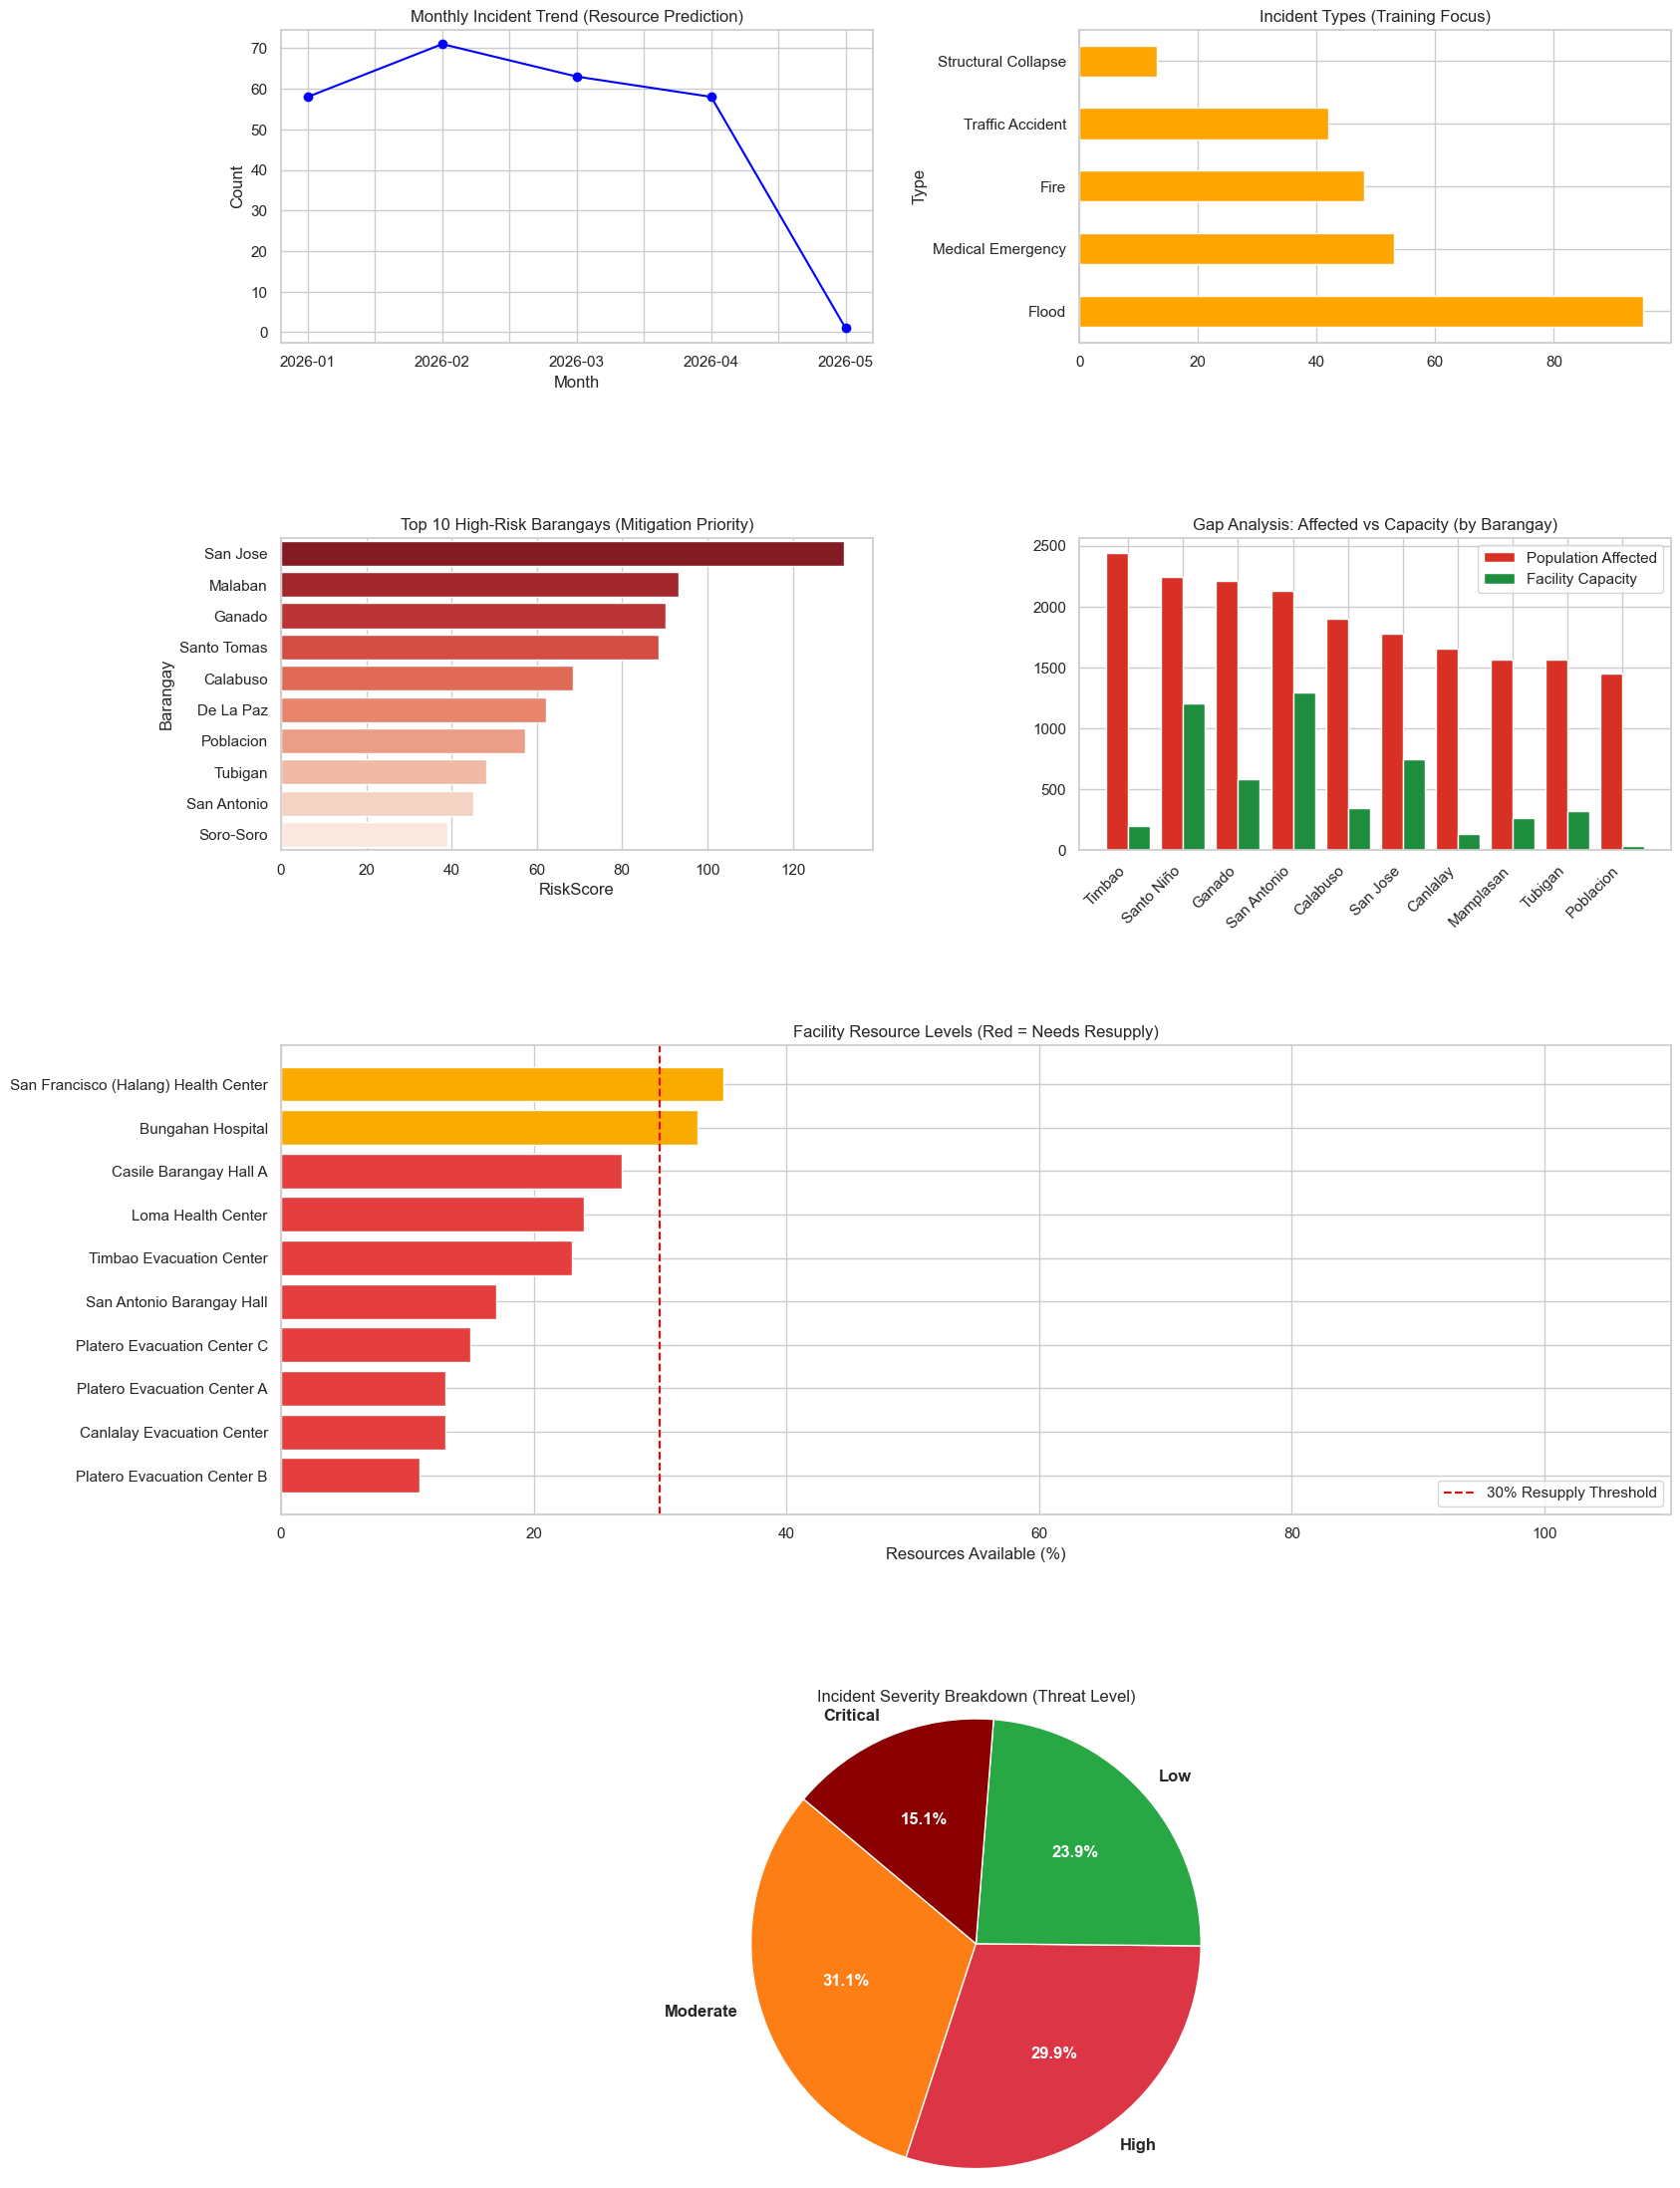

In [179]:
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(18, 28))
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1.5, 1.5], hspace=0.5, wspace=0.35)

# 1. Incident Trend Over Time
ax1 = fig.add_subplot(gs[0, 0])
df_incidents.groupby('Month').size().plot(kind='line', marker='o', color='blue', ax=ax1)
ax1.set_title('Monthly Incident Trend (Resource Prediction)')
ax1.set_ylabel('Count')

# 2. Incident Composition by Type
ax2 = fig.add_subplot(gs[0, 1])
df_incidents['Type'].value_counts().plot(kind='barh', color='orange', ax=ax2)
ax2.set_title('Incident Types (Training Focus)')

# 3. Top 10 High-Risk Barangays
ax3 = fig.add_subplot(gs[1, 0])
top_risk = df_brgy.sort_values(by='RiskScore', ascending=False).head(10)
sns.barplot(data=top_risk, x='RiskScore', y='Barangay', palette='Reds_r', ax=ax3)
ax3.set_title('Top 10 High-Risk Barangays (Mitigation Priority)')

# 4. Gap Analysis: Population Affected vs Facility Capacity by Barangay
ax4 = fig.add_subplot(gs[1, 1])
pop_affected = df_incidents.groupby('Barangay')['NumAffected'].sum()
cap_per_brgy = df_fac.groupby('Barangay')['Capacity'].sum()
gap_df = pd.DataFrame({'Population Affected': pop_affected, 'Facility Capacity': cap_per_brgy}).fillna(0)
gap_df = gap_df.sort_values('Population Affected', ascending=False).head(10)
x = range(len(gap_df))
width = 0.4
ax4.bar([i - width/2 for i in x], gap_df['Population Affected'], width=width, color='#d93025', label='Population Affected')
ax4.bar([i + width/2 for i in x], gap_df['Facility Capacity'], width=width, color='#1e8e3e', label='Facility Capacity')
ax4.set_xticks(ticks=x)
ax4.set_xticklabels(gap_df.index, rotation=45, ha='right')
ax4.set_title('Gap Analysis: Affected vs Capacity (by Barangay)')
ax4.legend()

# 5. Facilities Needing Resupply
ax5 = fig.add_subplot(gs[2, :])
resupply_df = df_fac[['Name', 'ResourcesAvailable']].sort_values('ResourcesAvailable').head(10)
colors_resupply = ['#e53e3e' if v < 30 else '#f9ab00' if v < 60 else '#1e8e3e' for v in resupply_df['ResourcesAvailable']]
ax5.barh(resupply_df['Name'], resupply_df['ResourcesAvailable'], color=colors_resupply)
ax5.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='30% Resupply Threshold')
ax5.set_xlabel('Resources Available (%)')
ax5.set_title('Facility Resource Levels (Red = Needs Resupply)')
ax5.legend(loc='lower right')
ax5.set_xlim(0, 110)

# 6. Incident Severity Breakdown
ax6 = fig.add_subplot(gs[3, :])
sev_counts = df_incidents['Severity'].value_counts()
color_map = {'Low': '#28a745', 'Moderate': '#fd7e14', 'High': '#dc3545', 'Critical': '#8b0000'}
colors = [color_map.get(x, 'gray') for x in sev_counts.index]
patches, texts, autotexts = ax6.pie(sev_counts, autopct='%1.1f%%', colors=colors, labels=sev_counts.index, startangle=140, radius=1.2)
plt.setp(autotexts, size=12, weight="bold", color="white")
plt.setp(texts, size=12, weight="bold")
ax6.set_title('Incident Severity Breakdown (Threat Level)')
ax6.set_ylabel('')

plt.tight_layout()
plt.show()


## 5. Interaction and Analytical Navigation (OLAP)
This interactive section demonstrates core OLAP capabilities required for our BI dashboard:
- **Slice:** By selecting a single dimension (e.g., Incident Type = 'Flood'), we slice the data block.
- **Dice:** By selecting multiple dimensions (e.g., Barangay = 'San Jose' AND Severity = 'Critical'), we dice the data into a smaller subcube.
- **Drill-down:** Users start at the summary KPIs, and use this section to drill down into the street-level coordinates and specific incident records.
- **Roll-up:** The line chart above rolls up daily incidents into a Monthly summary dimension.


In [180]:
# Define Interactive Widgets
sorted_brgys = sorted(list(df_incidents['Barangay'].unique()))
severity_levels = ["Low", "Moderate", "High", "Critical"]

# Derive sorted unique months (e.g. '01'..'12') and years from the data
all_months_str = sorted(df_incidents['DateTime'].dt.month.unique())
month_labels = [f"{m:02d}" for m in all_months_str]
all_years = sorted(df_incidents['DateTime'].dt.year.unique())

month_range_filter = widgets.SelectionRangeSlider(
    options=month_labels, index=(0, len(month_labels)-1),
    description='Month Range:', continuous_update=False,
    layout=widgets.Layout(width='500px')
)
year_range_filter = widgets.SelectionRangeSlider(
    options=all_years, index=(0, len(all_years)-1),
    description='Year Range:', continuous_update=False,
    layout=widgets.Layout(width='500px')
)
type_filter = widgets.Dropdown(options=['All'] + list(df_incidents['Type'].unique()), description='Incident Type:')
severity_filter = widgets.Dropdown(options=['All'] + severity_levels, description='Severity:')
brgy_filter = widgets.Dropdown(options=['All'] + sorted_brgys, description='Barangay:')
fac_type_filter = widgets.Dropdown(options=['All'] + list(df_fac['Type'].unique()), description='Facility:')

export_button = widgets.Button(description="Export to CSV", button_style='success', icon='download')
output_table = widgets.Output()
output_map = widgets.Output()
export_status = widgets.Output()

def get_filtered_data():
    filtered_df = df_incidents.copy()
    start_month, end_month = int(month_range_filter.value[0]), int(month_range_filter.value[1])
    start_year, end_year = year_range_filter.value[0], year_range_filter.value[1]
    filtered_df = filtered_df[
        (filtered_df['DateTime'].dt.month >= start_month) &
        (filtered_df['DateTime'].dt.month <= end_month) &
        (filtered_df['DateTime'].dt.year >= start_year) &
        (filtered_df['DateTime'].dt.year <= end_year)
    ]
    if type_filter.value != 'All':
        filtered_df = filtered_df[filtered_df['Type'] == type_filter.value]
    if severity_filter.value != 'All':
        filtered_df = filtered_df[filtered_df['Severity'] == severity_filter.value]
    if brgy_filter.value != 'All':
        filtered_df = filtered_df[filtered_df['Barangay'] == brgy_filter.value]
    return filtered_df

def update_dashboard(change):
    output_table.clear_output()
    output_map.clear_output()
    export_status.clear_output()
    
    filtered_df = get_filtered_data()
        
    with output_table:
        display(HTML(f"<h3>Filtered Records: {len(filtered_df)} incidents</h3>"))
        display(HTML(f"<p><i>Note for DRRMO Staff: Use the filters above to isolate incidents. Click 'Export to CSV' to save these records for your situation reports and deployment planning.</i></p>"))
        
        # Color-code the table severity for better UX
        def color_severity(val):
            color = ''
            bg = ''
            if val == 'Low': color, bg = 'green', '#e8f5e9'
            elif val == 'Moderate': color, bg = 'orange', '#fff3e0'
            elif val == 'High': color, bg = 'red', '#ffebee'
            elif val == 'Critical': color, bg = 'white', 'darkred'
            return f'color: {color}; background-color: {bg}; font-weight: bold;'
            
        if not filtered_df.empty:
            display(filtered_df.head(10).style.applymap(color_severity, subset=['Severity']))
        else:
            display(filtered_df.head(10))
        
    with output_map:
        # Create Folium Map
        if len(filtered_df) > 0:
            center_lat = filtered_df['Latitude'].mean()
            center_lon = filtered_df['Longitude'].mean()
        else:
            center_lat, center_lon = 14.3333, 121.0833
            
        m = folium.Map(location=[center_lat, center_lon], zoom_start=13)
        
        # Define UX-friendly severity colors and sizes
        sev_styles = {
            'Low': {'color': '#28a745', 'radius': 7},
            'Moderate': {'color': '#fd7e14', 'radius': 10},
            'High': {'color': '#dc3545', 'radius': 14},
            'Critical': {'color': '#8b0000', 'radius': 18}
        }
        
        # Plot filtered incidents
        for idx, row in filtered_df.iterrows():
            style = sev_styles.get(row['Severity'], {'color': 'gray', 'radius': 7})
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=style['radius'],
                color=style['color'],
                fill=True,
                fill_color=style['color'],
                fill_opacity=0.4,  # Lowered opacity for better overlap visibility
                weight=1.5,        # Thinner border for cleaner look
                popup=f"<b>{row['Type']}</b><br>Severity: <b>{row['Severity']}</b><br>Affected: {row['NumAffected']}"
            ).add_to(m)
            
        # Plot facilities with custom icons
        for idx, row in df_fac.iterrows():
            # Apply Barangay filter to facilities
            if brgy_filter.value != 'All' and row['Barangay'] != brgy_filter.value:
                continue
            
            # Apply Facility Type filter
            fac_type = row.get('Type', '')
            if fac_type_filter.value != 'All' and fac_type != fac_type_filter.value:
                continue
                
            icon_prefix = 'glyphicon'
            if fac_type == 'Hospital':
                icon_name, color = 'plus', 'red'
            elif fac_type == 'Evacuation Site':
                icon_name, color = 'home', 'green'
            elif fac_type == 'Fire Station':
                icon_name, color = 'fire', 'darkred'
            elif fac_type == 'School':
                icon_name, color, icon_prefix = 'building', 'orange', 'fa'
            elif fac_type == 'Command Center':
                icon_name, color, icon_prefix = 'building', 'blue', 'fa'
            elif fac_type == 'Health Care Center':
                icon_name, color, icon_prefix = 'heart', 'red', 'fa'
            else:
                icon_name, color = 'info-sign', 'green'
                
            folium.Marker(
                location=[row['Latitude'], row['Longitude']],
                icon=folium.Icon(color=color, icon=icon_name, prefix=icon_prefix),
                popup=f"{row['Name']} ({fac_type} | Cap: {row['Capacity']})"
            ).add_to(m)
            
        display(m)

def export_data(b):
    with export_status:
        export_status.clear_output()
        filtered_df = get_filtered_data()
        filename = f"DRRMO_Export_{brgy_filter.value}.csv".replace(' ', '_')
        filtered_df.to_csv(filename, index=False)
        print(f"✅ Successfully exported {len(filtered_df)} records to {filename}")

# Attach observers
month_range_filter.observe(update_dashboard, names='value')
year_range_filter.observe(update_dashboard, names='value')
type_filter.observe(update_dashboard, names='value')
severity_filter.observe(update_dashboard, names='value')
brgy_filter.observe(update_dashboard, names='value')
fac_type_filter.observe(update_dashboard, names='value')
export_button.on_click(export_data)

# Structured Filter Layout
filter_style = {'description_width': '110px'}
filter_layout = widgets.Layout(width='300px')
month_range_filter.style = filter_style
year_range_filter.style = filter_style
type_filter.style, type_filter.layout = filter_style, filter_layout
severity_filter.style, severity_filter.layout = filter_style, filter_layout
brgy_filter.style, brgy_filter.layout = filter_style, filter_layout
fac_type_filter.style, fac_type_filter.layout = filter_style, filter_layout

export_button.layout = widgets.Layout(width='300px', margin='10px 0 0 0')

filter_box = widgets.VBox([
    widgets.HTML("<h3>Interactive OLAP Filters</h3>"),
    month_range_filter,
    year_range_filter,
    widgets.HBox([type_filter, severity_filter]),
    widgets.HBox([brgy_filter, fac_type_filter]),
    export_button
], layout=widgets.Layout(padding='15px', border='2px solid #4CAF50', margin='0 0 20px 0', border_radius='10px', background_color='#f9f9f9'))

display(filter_box)
display(export_status)
display(output_table)
display(output_map)

# Trigger initial update
update_dashboard(None)


Output()

Output()

Output()

## 6. Operational Data Entry
The DRRM BI Dashboard also serves as an operational interface. Staff can use the forms below to register new facilities or report new incidents in real-time. The new records are appended to the datasets and a receipt is shown.


In [181]:
# Data Entry Forms
import datetime

display(HTML('''
<style>
.entry-scroll::-webkit-scrollbar { width: 6px; height: 6px; }
.entry-scroll::-webkit-scrollbar-track { background: transparent; border-radius: 10px; }
.entry-scroll::-webkit-scrollbar-thumb { background: #a0aec0; border-radius: 10px; }
.entry-scroll::-webkit-scrollbar-thumb:hover { background: #718096; }
</style>
'''))

sorted_brgys = sorted(list(df_brgy['Barangay'].unique()))
severity_levels = ["Low", "Moderate", "High", "Critical"]
fac_types = ["Evacuation Site", "School", "Command Center", "Hospital", "Health Care Center", "Fire Station"]

style = {'description_width': '80px'}
layout = widgets.Layout(width='280px', margin='0 10px 10px 0')

# Facility Form
fac_name_in = widgets.Text(description="Name:", style=style, layout=layout)
fac_brgy_in = widgets.Dropdown(options=sorted_brgys, description="Barangay:", style=style, layout=layout)
fac_type_in = widgets.Dropdown(options=fac_types, description="Type:", style=style, layout=layout)
fac_cap_in = widgets.IntText(description="Capacity:", style=style, layout=layout)
fac_lat_in = widgets.FloatText(value=14.3333, description="Latitude:", style=style, layout=layout)
fac_lon_in = widgets.FloatText(value=121.0833, description="Longitude:", style=style, layout=layout)
btn_add_fac = widgets.Button(description="Add Facility", button_style='primary', layout=widgets.Layout(width='280px', margin='10px 0 0 0'))

# Incident Form
inc_date_in = widgets.DatePicker(description="Date:", style=style, layout=layout)
inc_brgy_in = widgets.Dropdown(options=sorted_brgys, description="Barangay:", style=style, layout=layout)
inc_type_in = widgets.Dropdown(options=["Flood", "Medical Emergency", "Fire", "Traffic Accident", "Structural Collapse"], description="Type:", style=style, layout=layout)
inc_sev_in = widgets.Dropdown(options=severity_levels, description="Severity:", style=style, layout=layout)
inc_aff_in = widgets.IntText(description="Affected:", style=style, layout=layout)
inc_lat_in = widgets.FloatText(value=14.3333, description="Latitude:", style=style, layout=layout)
inc_lon_in = widgets.FloatText(value=121.0833, description="Longitude:", style=style, layout=layout)
btn_add_inc = widgets.Button(description="Add Incident", button_style='danger', layout=widgets.Layout(width='280px', margin='10px 0 0 0'))

out_receipt = widgets.Output()

def add_facility(b):
    with out_receipt:
        out_receipt.clear_output()
        new_fac = {
            'FacilityID': f"F{len(df_fac)+1:03d}",
            'Name': fac_name_in.value,
            'Barangay': fac_brgy_in.value,
            'Type': fac_type_in.value,
            'Capacity': fac_cap_in.value,
            'Latitude': fac_lat_in.value,
            'Longitude': fac_lon_in.value
        }
        pd.DataFrame([new_fac]).to_csv('facilities1.csv', mode='a', header=False, index=False)
        print(f"✅ RECEIPT: Added Facility '{new_fac['Name']}' ({new_fac['Type']}) to {new_fac['Barangay']}.")

def add_incident(b):
    with out_receipt:
        out_receipt.clear_output()
        dt_str = inc_date_in.value.strftime("%Y-%m-%d 12:00:00") if inc_date_in.value else "2026-05-01 12:00:00"
        new_inc = {
            'IncidentID': f"I{len(df_incidents)+1:03d}",
            'DateTime': dt_str,
            'Barangay': inc_brgy_in.value,
            'Type': inc_type_in.value,
            'Severity': inc_sev_in.value,
            'NumAffected': inc_aff_in.value,
            'Latitude': inc_lat_in.value,
            'Longitude': inc_lon_in.value
        }
        pd.DataFrame([new_inc]).to_csv('incidents1.csv', mode='a', header=False, index=False)
        print(f"🚨 RECEIPT: Logged new {new_inc['Severity']} {new_inc['Type']} incident at {new_inc['Barangay']} affecting {new_inc['NumAffected']} people.")

btn_add_fac.on_click(add_facility)
btn_add_inc.on_click(add_incident)

# Structured Layout Forms
fac_box = widgets.VBox([
    widgets.HTML("<h3>Add New Facility</h3>"),
    widgets.HBox([fac_name_in, fac_brgy_in, fac_type_in]),
    widgets.HBox([fac_cap_in, fac_lat_in, fac_lon_in]),
    btn_add_fac
], layout=widgets.Layout(padding='15px', border='1px solid #ccc', margin='0 0 20px 0', border_radius='5px', overflow='auto'))
fac_box.add_class('entry-scroll')

inc_box = widgets.VBox([
    widgets.HTML("<h3>Log New Incident</h3>"),
    widgets.HBox([inc_date_in, inc_brgy_in, inc_type_in]),
    widgets.HBox([inc_sev_in, inc_aff_in, inc_lat_in, inc_lon_in]),
    btn_add_inc
], layout=widgets.Layout(padding='15px', border='1px solid #ccc', margin='0 0 20px 0', border_radius='5px', overflow='auto'))
inc_box.add_class('entry-scroll')

display(fac_box)
display(inc_box)
display(out_receipt)


Output()

## 7. DRRM Interpretation & Reflection

### Key Findings and Recommendations
- Barangays with **Critical** hazard levels and high population density consistently score highest in the Risk Score metric, indicating they should be prioritized for pre-positioning of rescue teams and evacuation supplies.
- Incident data reveals that **floods and medical emergencies** are the most frequent incident types, suggesting the DRRMO should invest in water rescue training and mobile health response units.
- Several barangays show a significant gap between facility capacity and population size, meaning current evacuation infrastructure may be insufficient during large-scale disasters.
- **Recommendation:** Allocate additional evacuation sites and standby rescue teams to the top 5 high-risk barangays identified in Section 4.

### How the Notebook Dashboard Helps DRRMO Decision-Making
- The **KPI panel** (Section 3) gives commanders an at-a-glance operational status — available teams, total capacity, and critical incidents — enabling faster situational awareness.
- The **interactive OLAP filters** (Section 5) allow staff to slice and dice incident data by barangay, severity, and type, supporting both tactical (daily) and operational (weekly) decision cycles.
- The **geospatial map** overlays incident hotspots with facility locations, helping incident commanders identify coverage gaps and deploy resources efficiently.
- The **data entry forms** (Section 6) enable real-time logging, ensuring the dashboard reflects current ground conditions rather than stale historical data.

### Limitations and Future Improvements
- **Simulated Data:** The current dataset is synthetically generated. Integration with the actual DRRMO incident reporting system would significantly improve accuracy and reliability.
- **Static Visualizations:** Charts in Section 4 are static. Future versions should use fully interactive libraries (e.g., Plotly, Bokeh) for drill-down capability directly on the charts.
- **No Predictive Analytics:** The dashboard is currently descriptive and diagnostic. A future improvement would incorporate predictive models (e.g., flood risk forecasting using weather API data) to shift toward a prescriptive BI tier.
- **Single-user Environment:** The notebook runs locally. Deploying it as a web application (e.g., via Voilà or Streamlit) would allow multi-user access for all DRRMO officers simultaneously.
